In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 83


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

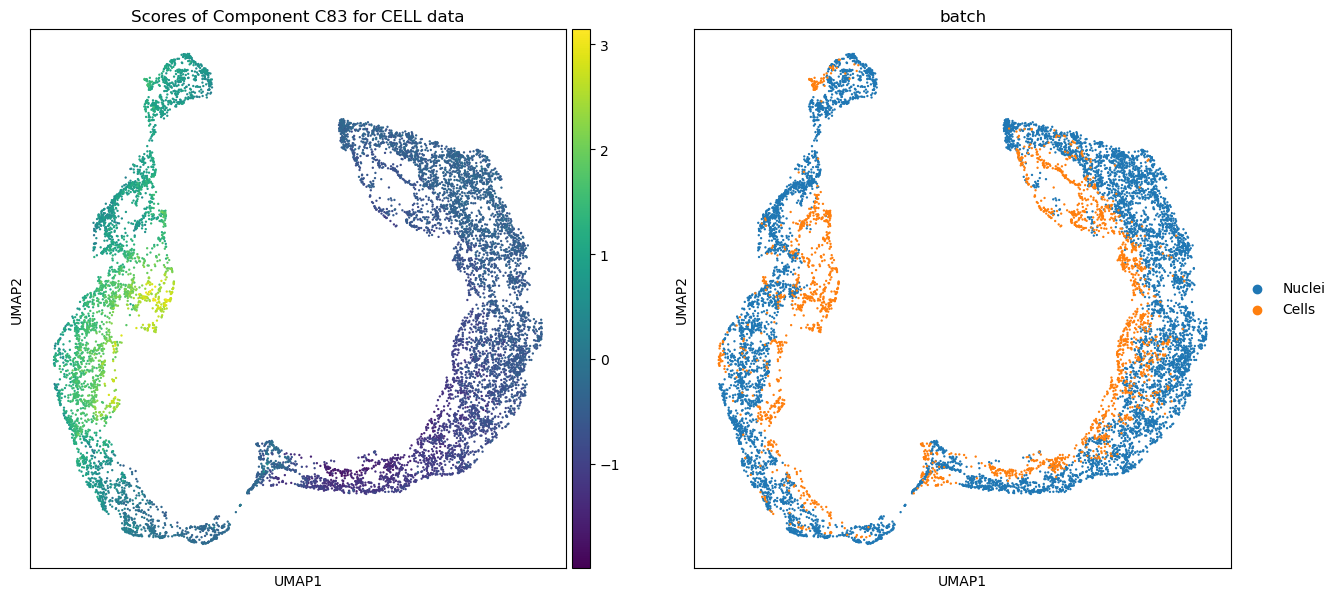

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

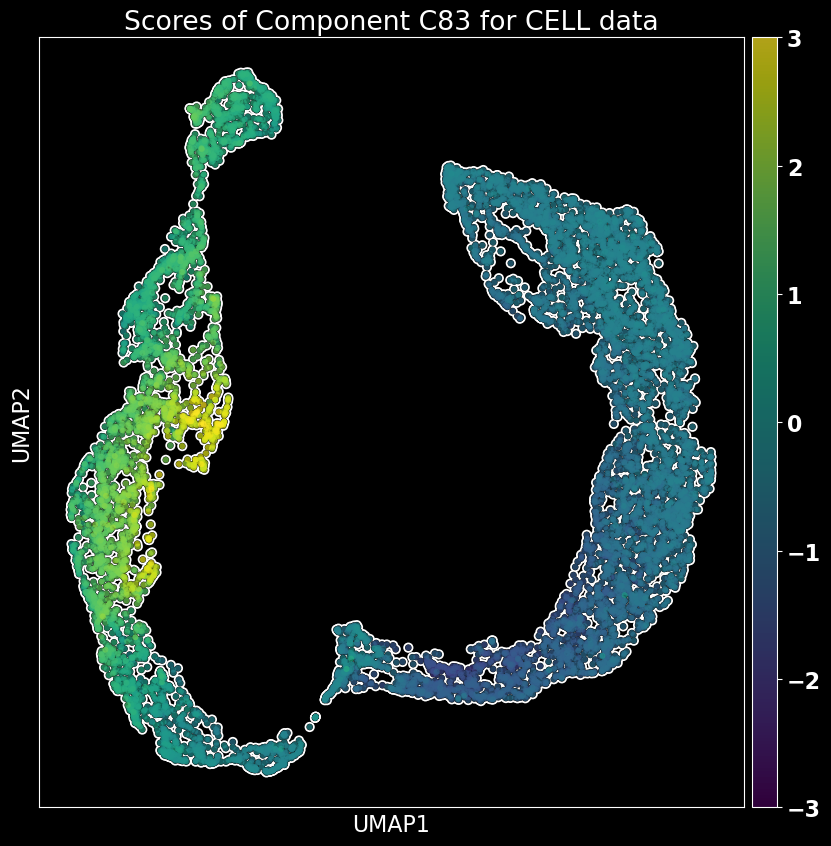

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

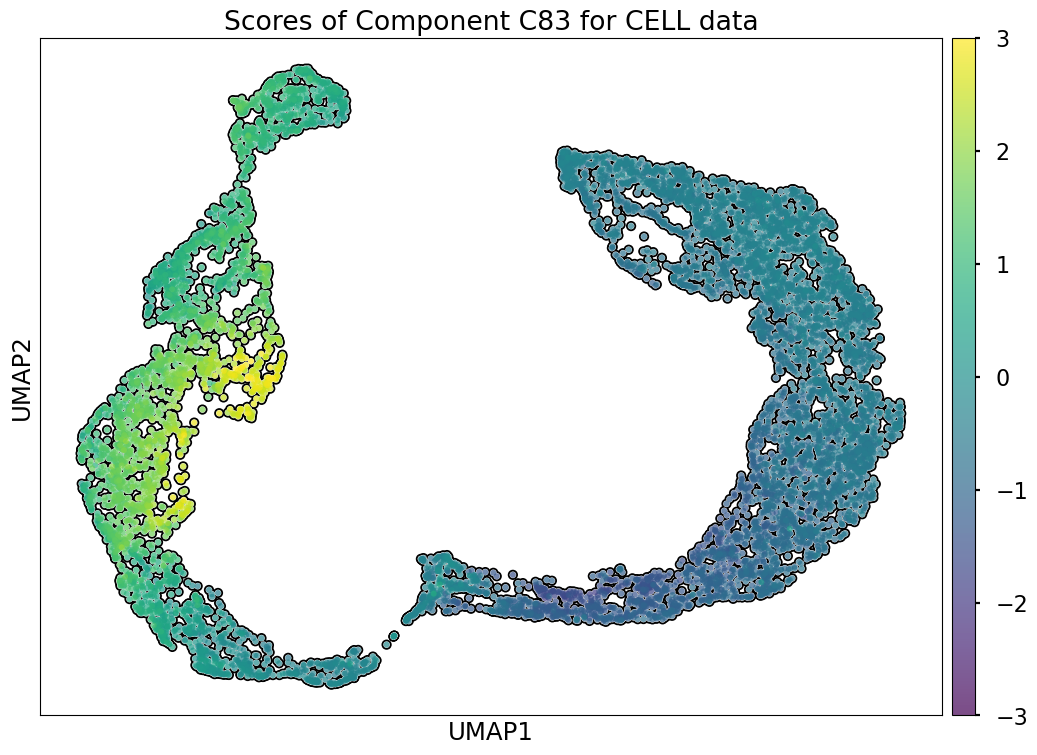

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

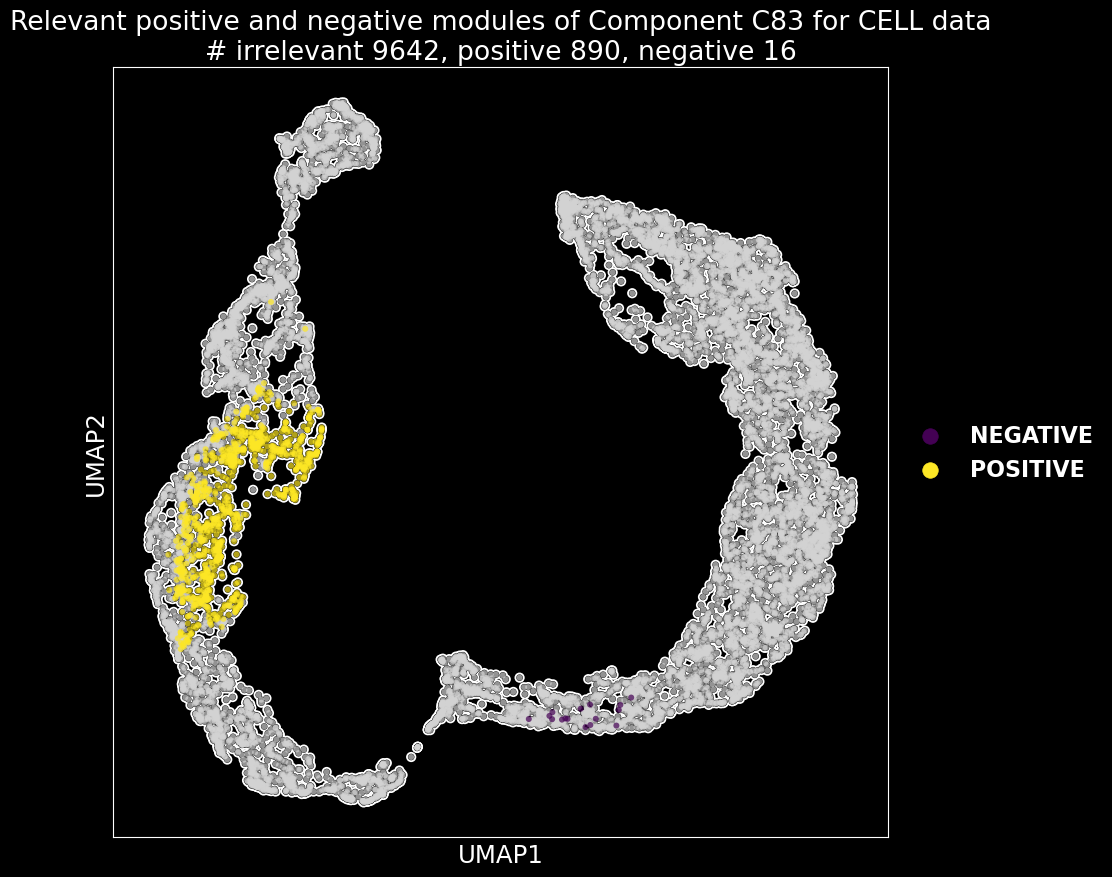

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

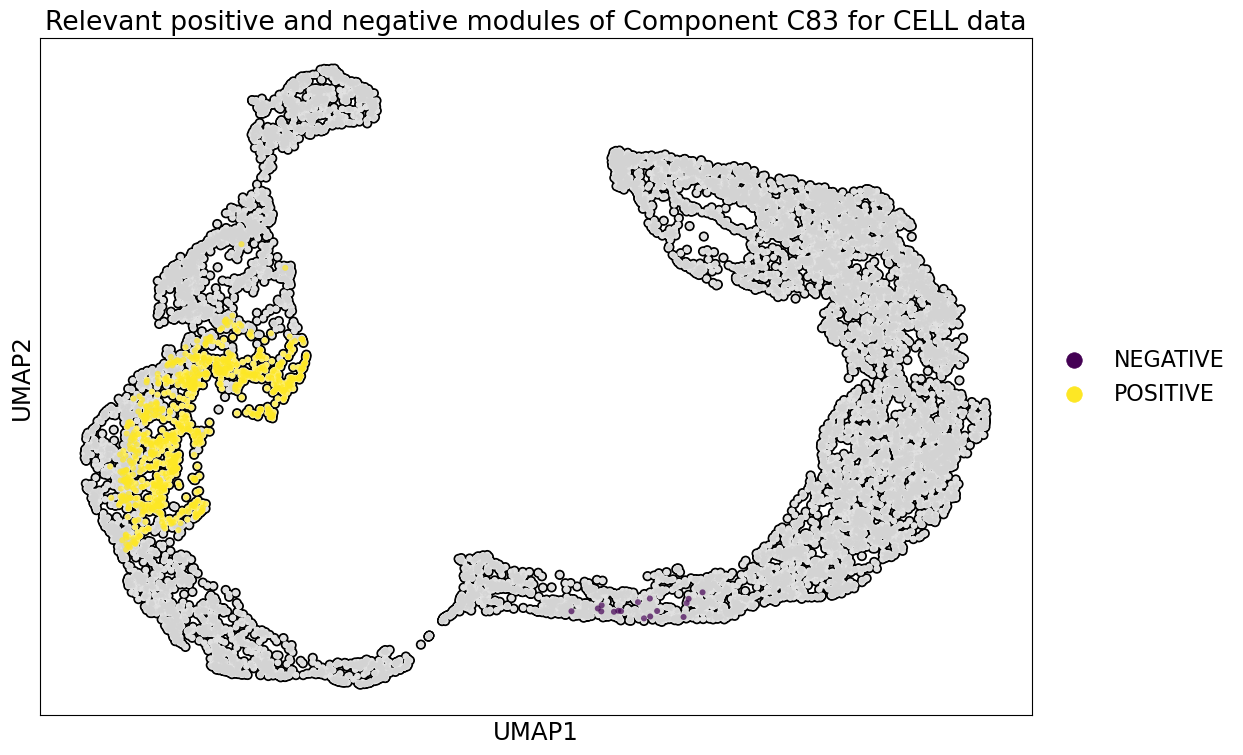

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 1.7493224021352314 var: 0.18147308319402372
Positive scores cells  - mean: 2.444493902439025 var: 0.25765598451563704


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.561791875 var: 0.04286890265955466
Negative scores cells  - mean: nan var: nan


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=31.84695125631338, pvalue=2.8820390419359696e-197)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-36.04420897747233, pvalue=1.8450973558024847e-260)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: Yes


<Axes: xlabel='SDA_cellscore_C83', ylabel='Count'>

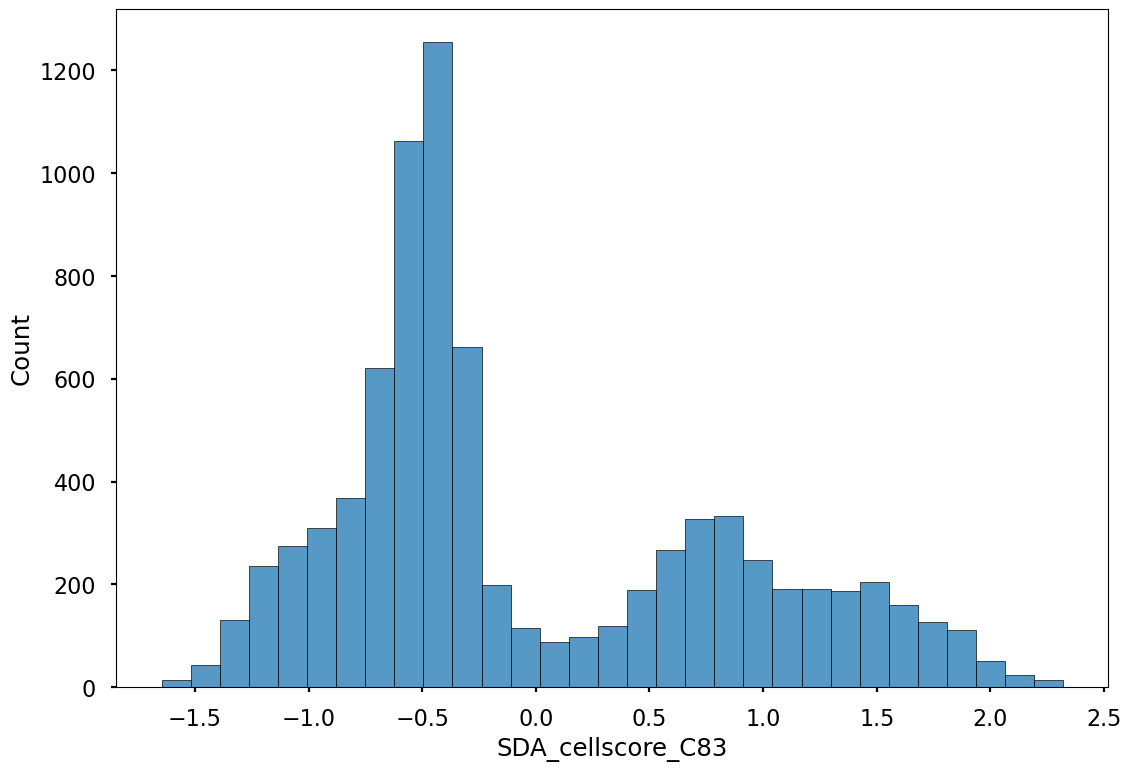

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C83', ylabel='Count'>

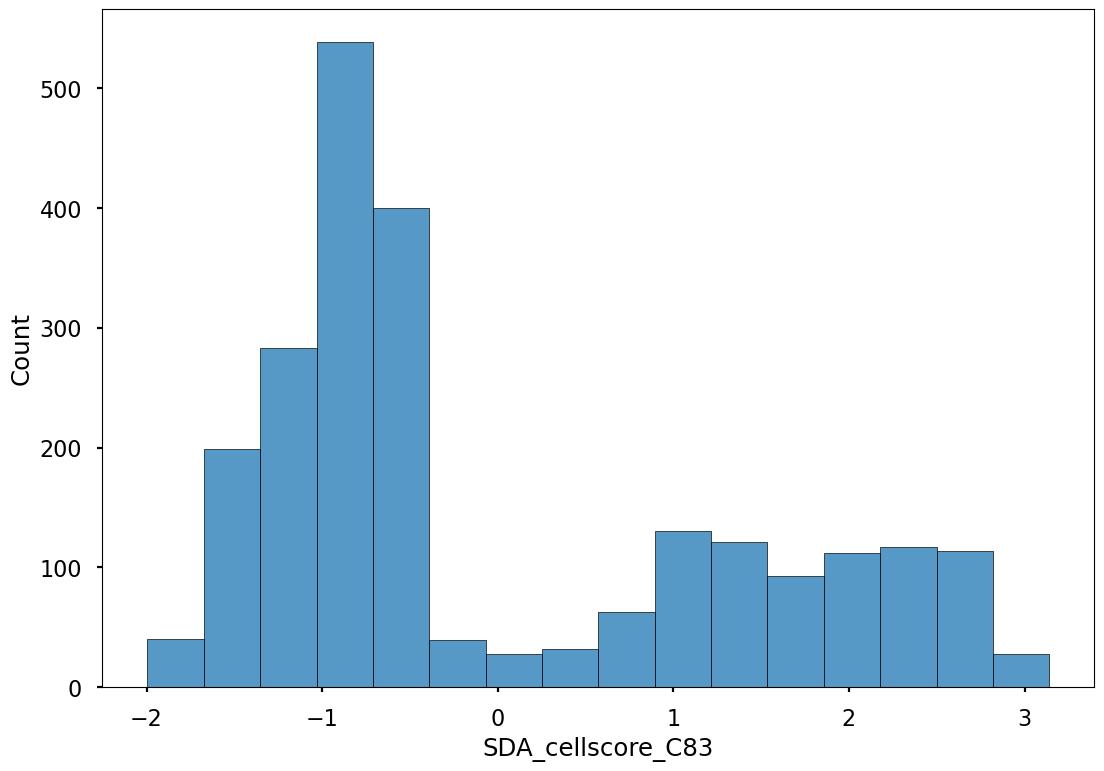

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C83: 1578


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

MRPL20
LOC469457
GNB1
LOC107974735
CAMTA1
PER3
PARK7
CTNNBIP1
LZIC
KIF1B
SDF4
PLEKHM2
SPEN
UBR4
DDOST
HP1BP3
CDC42
KDM1A
HNRNPR
SRSF10
SRRM1
MACO1
CEP85
NUDC
RPA2
EYA3
DNAJC8
PHACTR4
TAF12
YTHDF2
EPB41
SNRNP40
PTP4A2
KHDRBS1
RBBP4
S100PBP
ZMYM1
SFPQ
ZMYM4
KIAA0319L
PSMB2
CLSPN
AGO4
CDCA8
SF3A3
MACF1
PABPC4
SCMH1
HIVEP3
FOXJ3
ST3GAL3
ATP6V0B
ZSWIM5
NASP
LRRC41
STIL
EPS15
LOC107966681
ZFYVE9
SCP2
DMRTB1
HSPB11
TMEM59
USP24
FGGY
DOCK7
SERBP1
DEPDC1
LOC104001211
MSH4
PIGK
ZNHIT6
COL24A1
LOC100615600
PKN2
ZNF326
HFM1
BTBD8
GLMN
RPAP2
RPL5
MTF2
LOC100612616
FNBP1L
ARHGAP29
PTBP2
DPYD
SASS6
ST7L
DENND2C
CSDE1
SYCP1
MAN1A2
LOC112208384
RNF115
RBM8A
LOC738370
OTUD7B
RPRD2
GOLPH3L
HORMAD1
PIP5K1A
POGZ
TCHH
ILF2
GATAD2B
RPS27
ASH1L
YY1AP1
CCT3
ARHGEF11
PFDN2
UAP1
LOC107969123
NUF2
TMCO1
POU2F1
KIFAP3
KLHL20
TDRD5
ACBD6
ARPC5
TPR
NEK7
CAMSAP2
IPO9
KDM5B
MDM4
SYT14
LPGAT1
DTL
LYPLAL1
EPRS
MARK1
AIDA
GNPAT
EGLN1
ARID4B
LYST
HEATR1
MTR
RYR2
LOC104004798
CHRM3
COX20
HNRNPU
SMYD3
MYT1L
RNF144A
KIDINS22

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C83: 1191


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

AURKAIP1
CENPS
TTLL10
C1H1orf159
FHAD1
CAPZB
KIF17
EPHB2
LUZP1
STPG1
FAM76A
ATP5IF1
PHC2
HMGB4
STK40
OSCP1
DNALI1
MTF1
MYCBP
CCDC30
CFAP57
CCDC24
RNF220
ARMH1
TESK2
FAAH
OSBPL9
NRDC
ECHDC2
GLIS1
MROH7
LEXM
JUN
LOC742772
UBE2U
CACHD1
LOC107966995
WDR78
SLC35D1
C1H1orf141
LRRC7
NEGR1
LRRIQ3
DNAJB4
TTLL7
SPATA1
SSX2IP
WDR63
ODF2L
HS2ST1
LRRC8B
CDC14A
EXTL2
LOC104001730
LOC457936
C1H1orf194
KIAA1324
GSTM4
GSTM3
PIFO
TMIGD3
LOC112204994
PHTF1
FAM46C
SPAG17
LOC742917
PLEKHO1
MRPS21
C1H1orf56
PSMD4
OAZ3
LOC747877
PBXIP1
KRTCAP2
CFAP45
PBX1
LOC104003547
ADCY10
LOC469572
NME7
CCDC181
MROH9
DNM3
SLC9C2
ANKRD45
TNR
AXDND1
LOC107973782
RGL1
EDEM3
LOC112206075
CDC73
KCNT2
PLEKHA6
DYRK3
KCNH1
LOC745816
FAM71A
VASH2
ESRRG
GPATCH2
SPATA17
RRP15
SLC30A10
MIA3
ENAH
SLC35F3
GGPS1
B3GALNT2
C1H1orf100
RPS7
ASAP2
ODC1
LAPTM4A
LOC104004902
FAM228B
PFN4
DRC1
ABHD1
PRR30
IFT172
C2AH2orf16
LOC107973427
CEBPZOS
NDUFAF7
RMDN2
GEMIN6
DYNC2LI1
TMEM247
ATP6V1E2
TTC7A
STPG4
GTF2A1L
ACYP2
CFAP36
KIAA1841
FAM161A
WDPCP

#### Cells scores by cluster

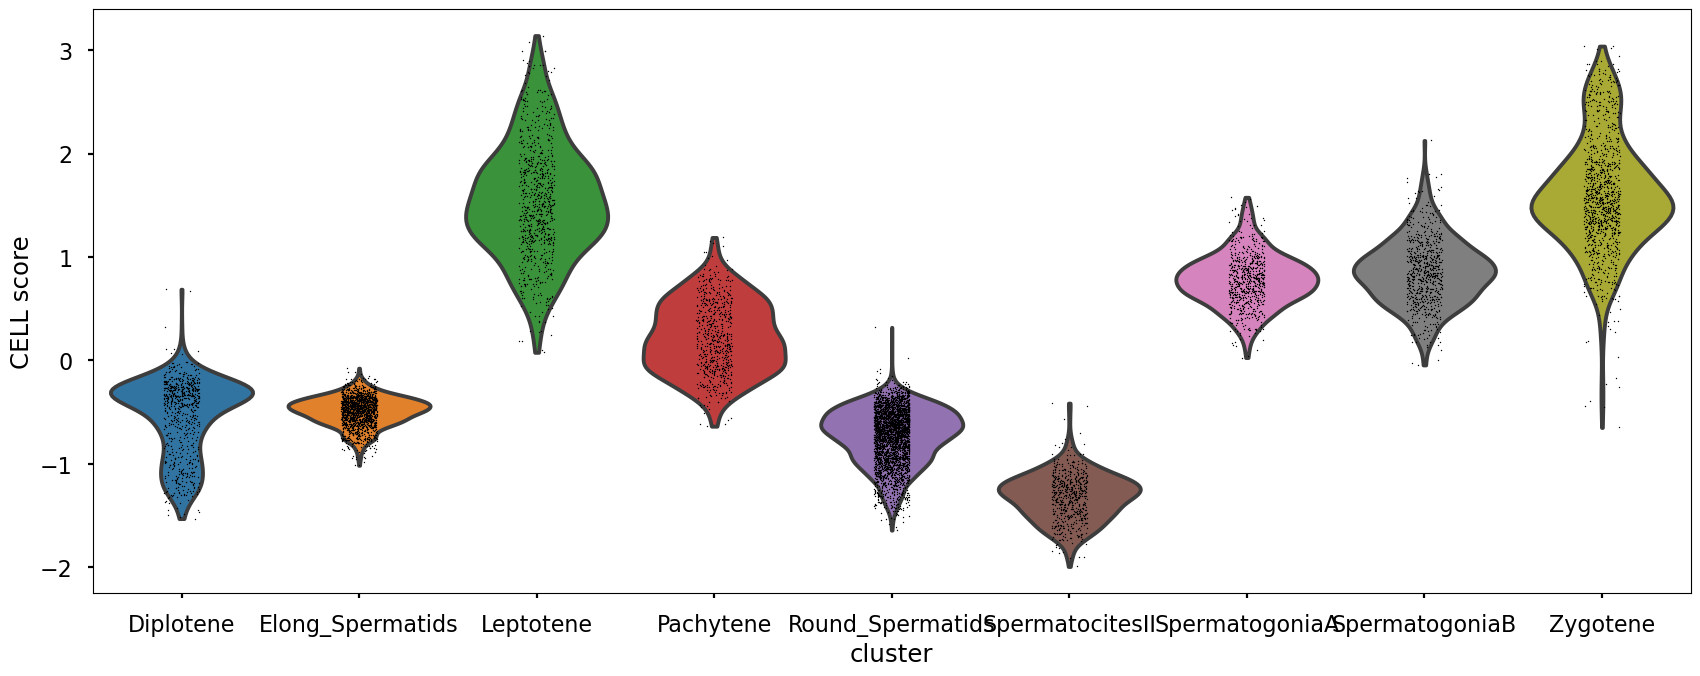

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

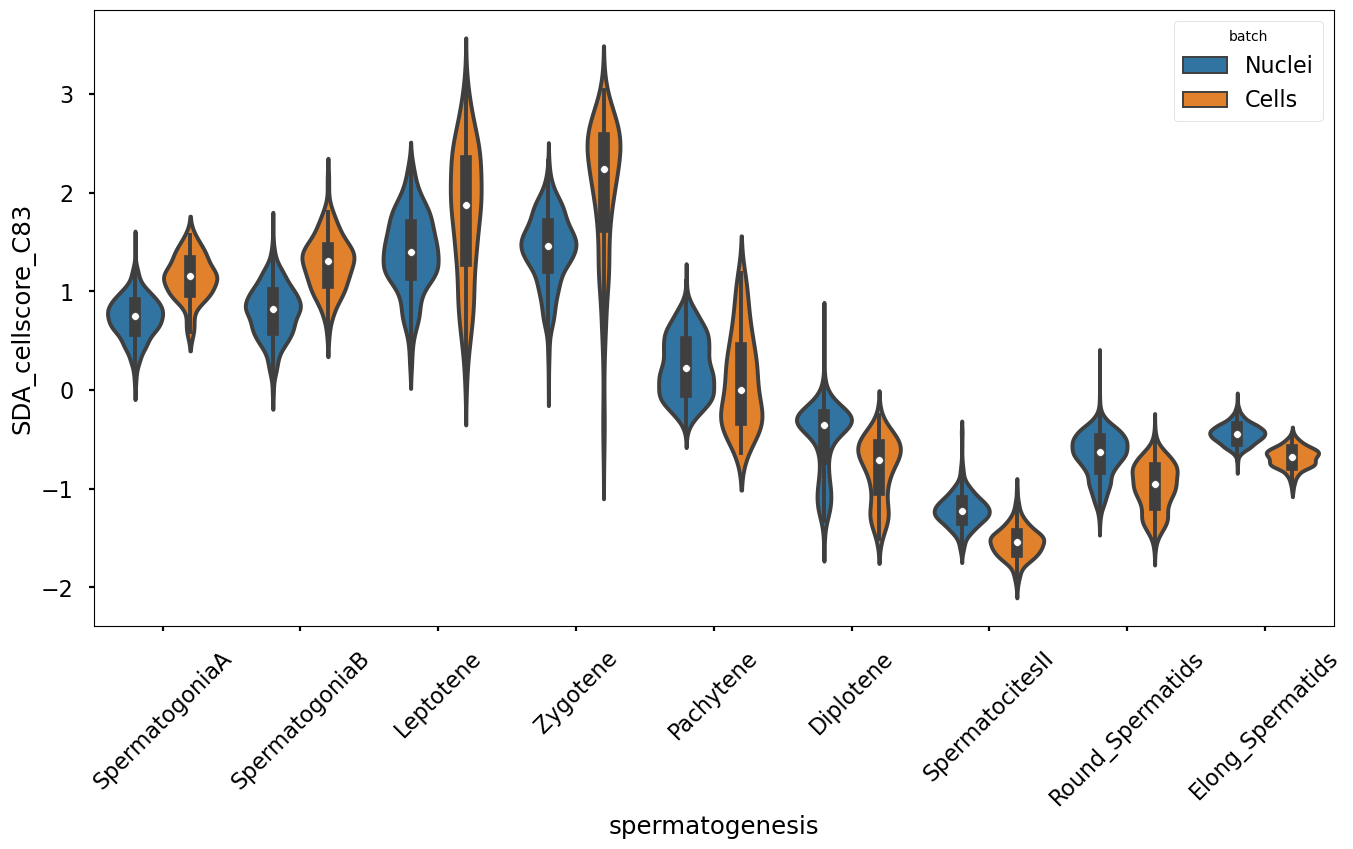

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C83')

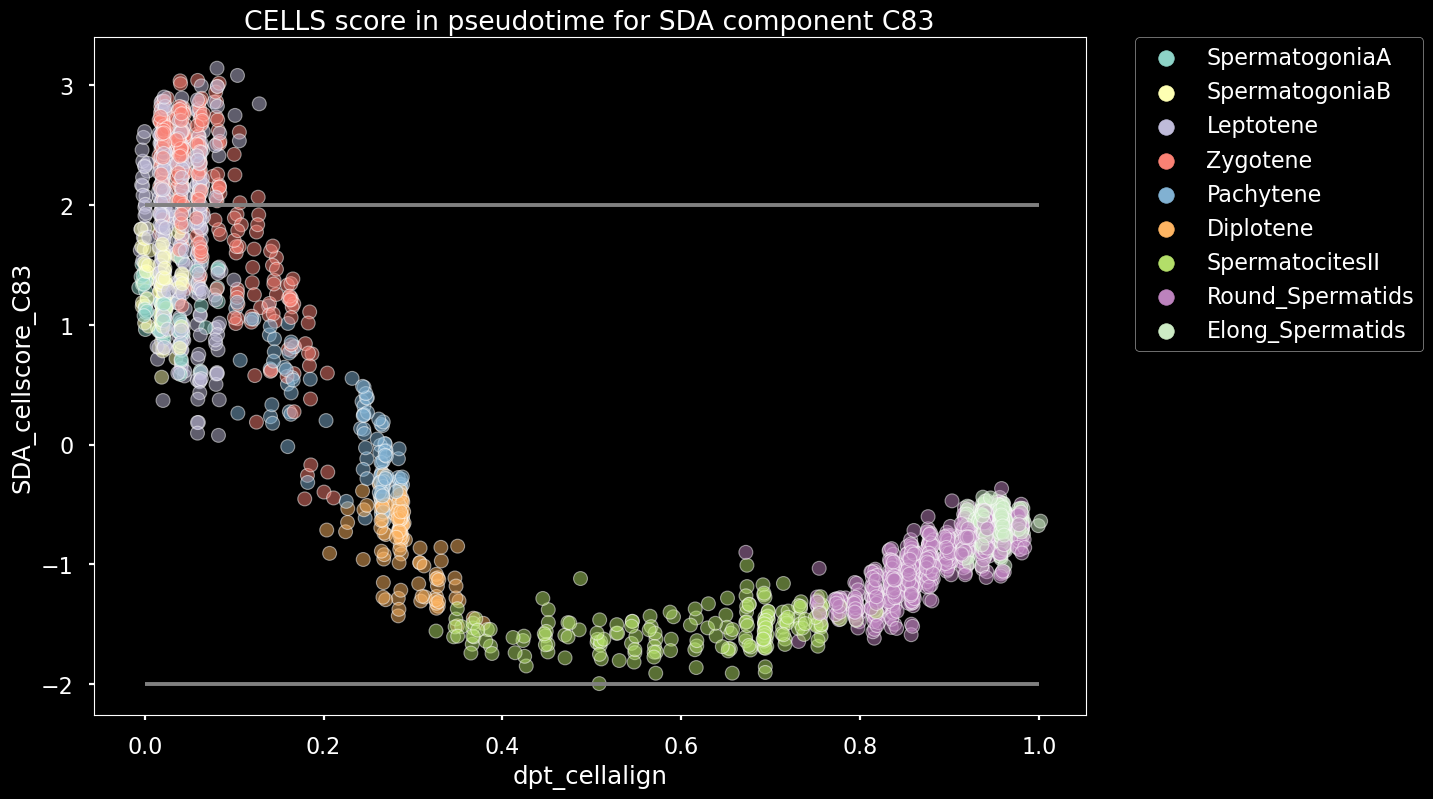

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C83')

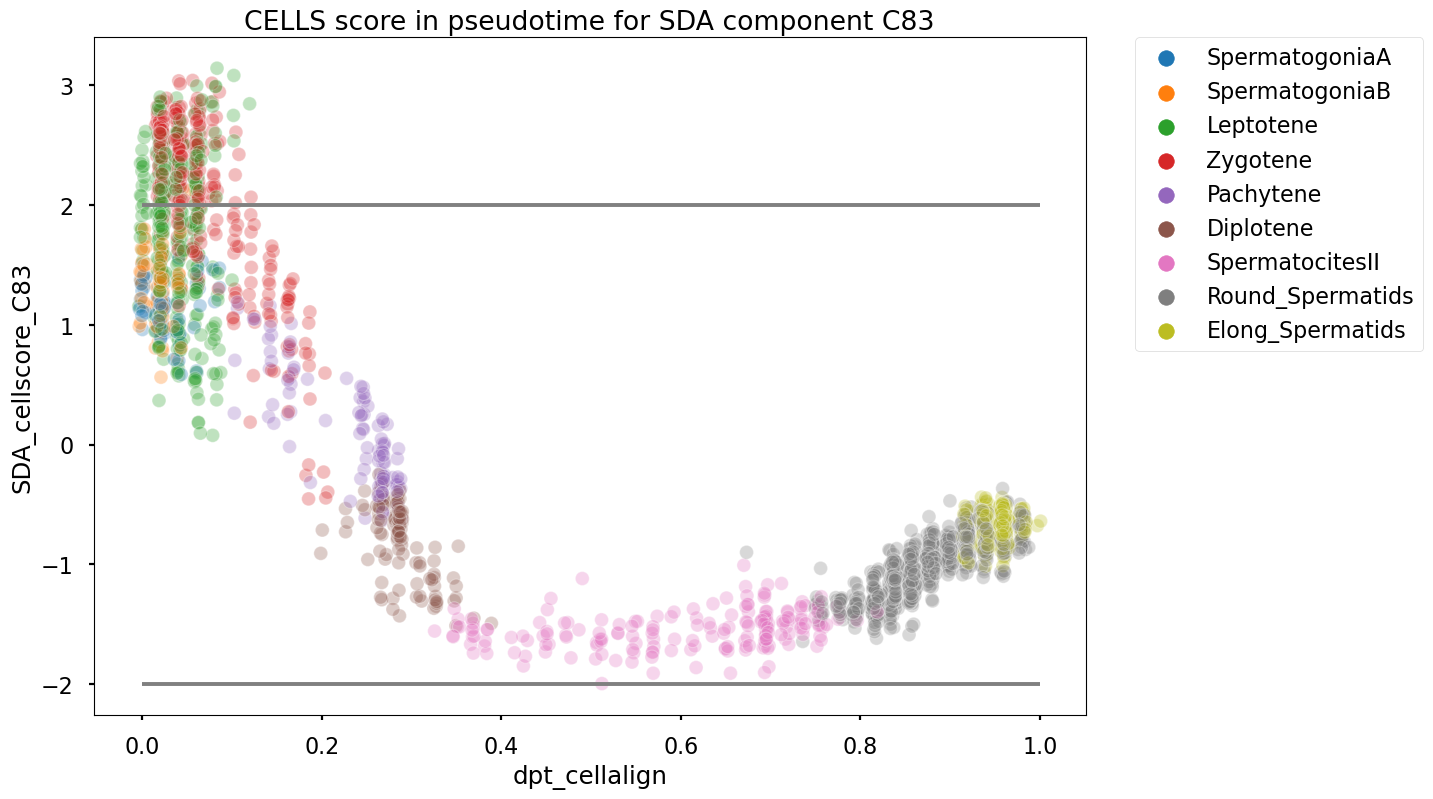

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C83')

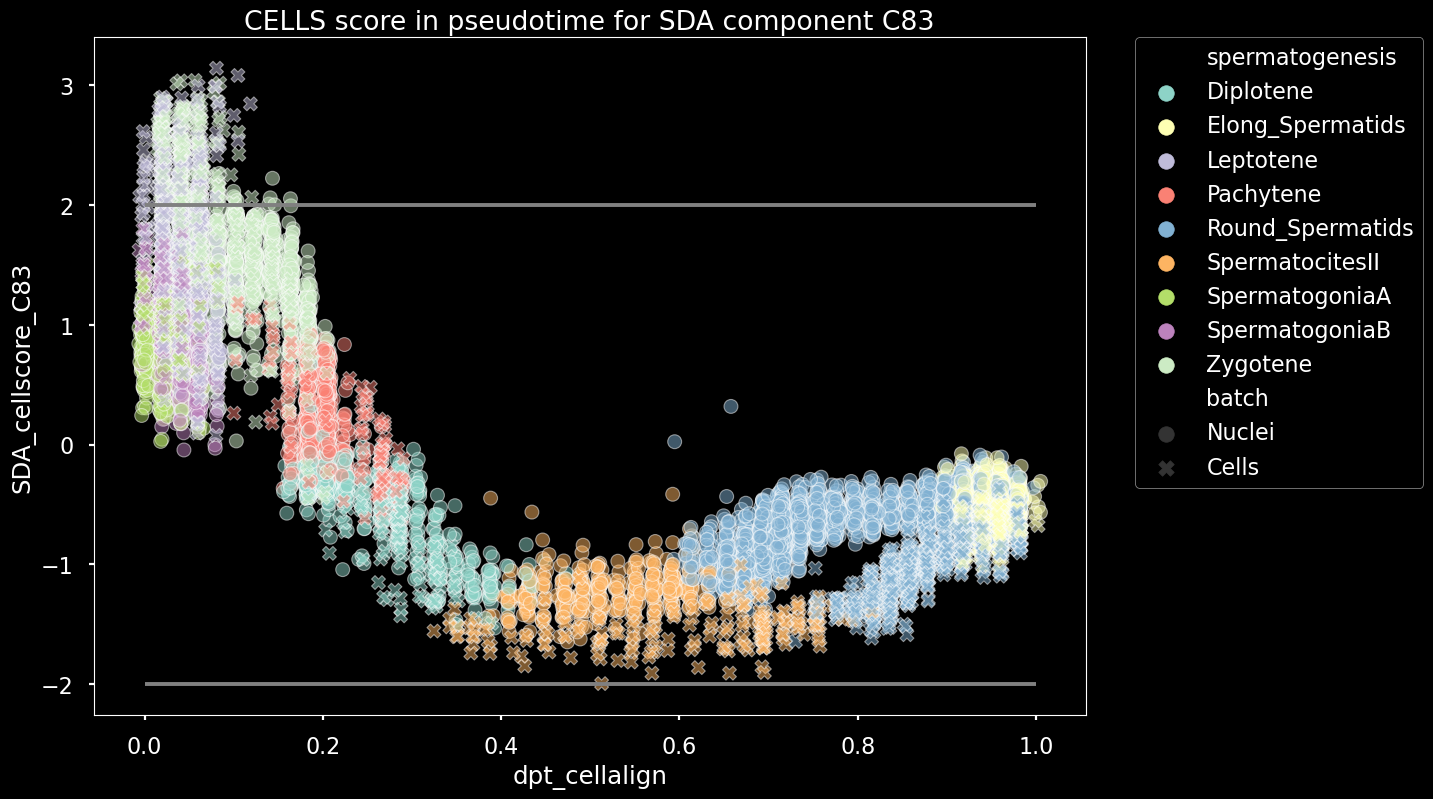

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C83')

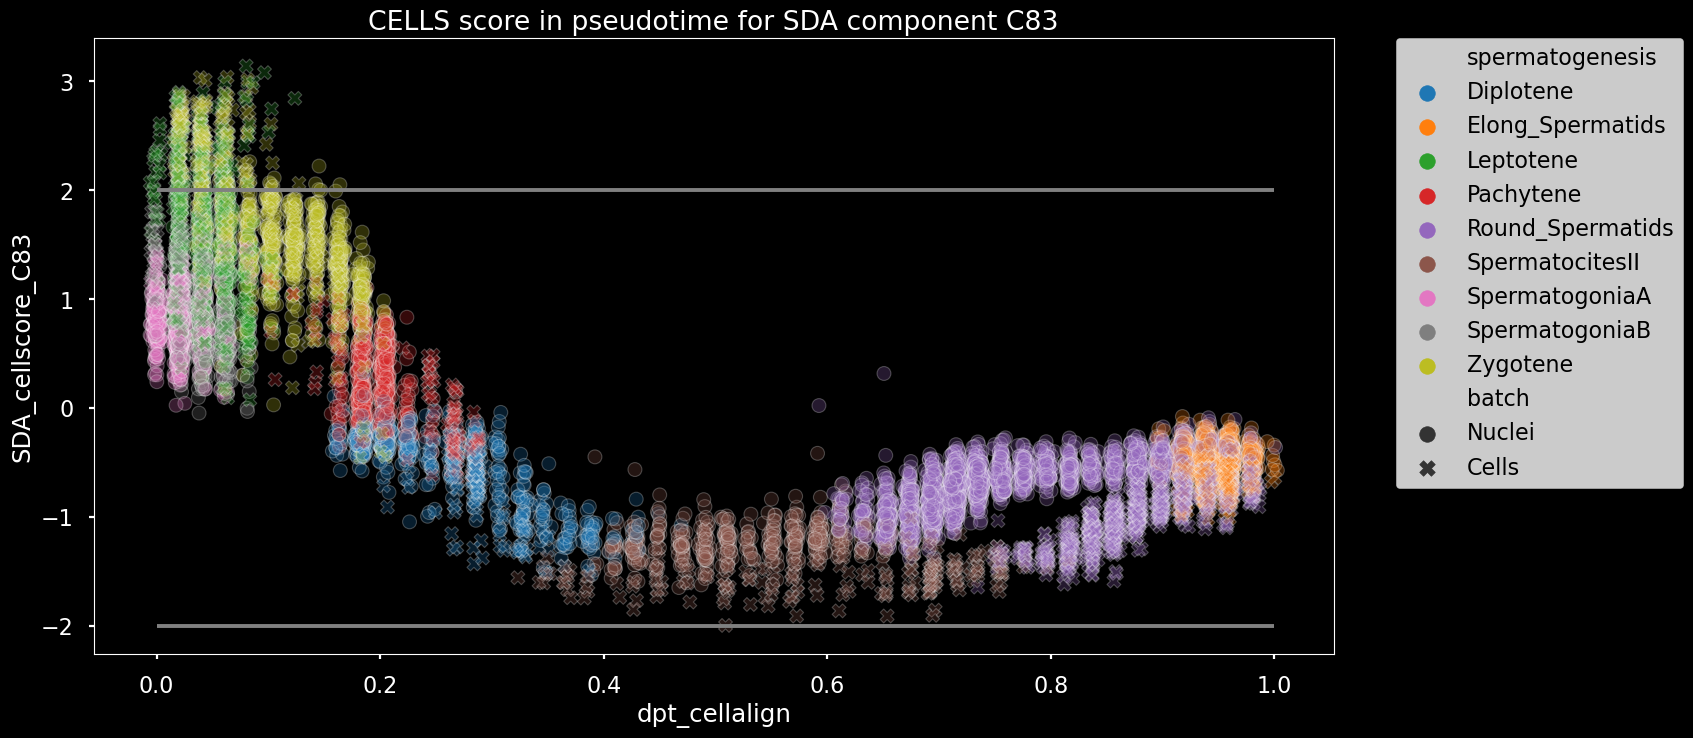

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Spliceosome,34/150,1.536616e-08,4.256426e-06,0,0,3.475098,62.520834,RBM25;SF3B2;RBM8A;DDX46;DDX42;HNRNPU;PRPF8;SNR...
277,GO_Cellular_Component_2023,Nucleus (GO:0005634),527/4487,1.366890e-25,4.961809e-23,0,0,1.831222,104.841304,MDC1;RPL5;TRRAP;MYT1L;ZNF292;HNRNPU;HNRNPR;PHA...
278,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,586/5175,5.983491e-25,1.086004e-22,0,0,1.780673,99.318167,ITSN2;VPS29;MDC1;RPL5;CHIC2;SLC4A1AP;ZFYVE9;TR...
279,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,177/1195,6.586499e-17,7.969664e-15,0,0,2.159914,80.476067,MDC1;RPL5;SMARCB1;ZMYND8;BUB1B;HNRNPR;ADARB1;A...
280,GO_Cellular_Component_2023,Chromosome (GO:0005694),45/164,5.871521e-14,5.328405e-12,0,0,4.514874,137.550515,TOP2A;MDC1;SETD2;CDCA2;SPO11;SYCP1;HP1BP3;HMGB...
281,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),115/780,3.551850e-11,2.578643e-09,0,0,2.098947,50.502695,RPL5;SMARCB1;ZMYND8;HNRNPU;HNRNPR;ADARB1;ADARB...
282,GO_Cellular_Component_2023,Nucleolus (GO:0005730),111/771,3.344388e-10,1.746209e-08,0,0,2.036295,44.429050,RPL5;SMARCB1;ZMYND8;HNRNPR;ADARB1;ADARB2;RRP8;...
283,GO_Cellular_Component_2023,Cytoplasmic Stress Granule (GO:0010494),25/76,3.367345e-10,1.746209e-08,0,0,5.798707,126.479813,DDX6;VCP;NUFIP2;ROCK1;STAU1;CELF1;DDX1;ELAVL1;...
284,GO_Cellular_Component_2023,Condensed Chromosome (GO:0000793),20/60,1.510413e-08,6.853500e-07,0,0,5.899230,106.235085,SLF2;XRCC4;CBX3;NCAPG2;NSMCE2;HMGB2;NCAPG;HMGB...
285,GO_Cellular_Component_2023,Nuclear Chromosome (GO:0000228),25/95,5.507289e-08,2.221273e-06,0,0,4.220403,70.542382,TOP2A;SPO11;TRRAP;NCAPG2;HNRNPU;NCAPG;SMC4;NCA...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Spliceosome,34/150,4.256426e-06,3.475098,62.520834,RBM25;SF3B2;RBM8A;DDX46;DDX42;HNRNPU;PRPF8;SNR...,83P,Yes,890
277,GO_Cellular_Component_2023,Nucleus (GO:0005634),527/4487,4.961809e-23,1.831222,104.841304,MDC1;RPL5;TRRAP;MYT1L;ZNF292;HNRNPU;HNRNPR;PHA...,83P,Yes,890
278,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,586/5175,1.086004e-22,1.780673,99.318167,ITSN2;VPS29;MDC1;RPL5;CHIC2;SLC4A1AP;ZFYVE9;TR...,83P,Yes,890
279,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,177/1195,7.969664e-15,2.159914,80.476067,MDC1;RPL5;SMARCB1;ZMYND8;BUB1B;HNRNPR;ADARB1;A...,83P,Yes,890
280,GO_Cellular_Component_2023,Chromosome (GO:0005694),45/164,5.328405e-12,4.514874,137.550515,TOP2A;MDC1;SETD2;CDCA2;SPO11;SYCP1;HP1BP3;HMGB...,83P,Yes,890
281,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),115/780,2.578643e-09,2.098947,50.502695,RPL5;SMARCB1;ZMYND8;HNRNPU;HNRNPR;ADARB1;ADARB...,83P,Yes,890
282,GO_Cellular_Component_2023,Nucleolus (GO:0005730),111/771,1.746209e-08,2.036295,44.429050,RPL5;SMARCB1;ZMYND8;HNRNPR;ADARB1;ADARB2;RRP8;...,83P,Yes,890
283,GO_Cellular_Component_2023,Cytoplasmic Stress Granule (GO:0010494),25/76,1.746209e-08,5.798707,126.479813,DDX6;VCP;NUFIP2;ROCK1;STAU1;CELF1;DDX1;ELAVL1;...,83P,Yes,890
284,GO_Cellular_Component_2023,Condensed Chromosome (GO:0000793),20/60,6.853500e-07,5.899230,106.235085,SLF2;XRCC4;CBX3;NCAPG2;NSMCE2;HMGB2;NCAPG;HMGB...,83P,Yes,890
285,GO_Cellular_Component_2023,Nuclear Chromosome (GO:0000228),25/95,2.221273e-06,4.220403,70.542382,TOP2A;SPO11;TRRAP;NCAPG2;HNRNPU;NCAPG;SMC4;NCA...,83P,Yes,890


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
254,GO_Cellular_Component_2023,Cilium (GO:0005929),59/257,1.175441e-19,2.997374e-17,0,0,4.899030,213.536343,FANK1;TTC26;IFT172;CEP19;KIF17;DNALI1;CFAP47;B...
255,GO_Cellular_Component_2023,9+2 Motile Cilium (GO:0097729),28/70,9.065354e-17,1.155833e-14,0,0,10.757810,397.387988,DNAH1;SPEF2;DNAH2;DNAH8;DNHD1;DNAH9;RSPH9;TTC2...
256,GO_Cellular_Component_2023,Acrosomal Vesicle (GO:0001669),22/64,6.660362e-12,5.661307e-10,0,0,8.409182,216.409006,SPAG17;LRGUK;SPINK2;ACTL7A;SPESP1;CCDC136;SPAC...
257,GO_Cellular_Component_2023,Sperm Flagellum (GO:0036126),21/60,1.347279e-11,8.588906e-10,0,0,8.638396,216.222059,DNAI2;DNAH1;SPEF2;DNAH2;DNAH17;DNAH8;DNHD1;ATP...
258,GO_Cellular_Component_2023,Motile Cilium (GO:0031514),23/73,1.735565e-11,8.851380e-10,0,0,7.387962,183.052305,DYNC2H1;CFAP61;CFAP52;DNAH2;DNAH17;WDR19;DNAH9...
259,GO_Cellular_Component_2023,Outer Dynein Arm (GO:0036157),6/8,1.111722e-06,4.724819e-05,0,0,47.612658,652.750515,DNAI2;DNAH17;DNAH8;NME8;DNAI1;DNAL1
509,Human_Gene_Atlas,TestisIntersitial,106/568,1.819148e-26,1.455319e-24,0,0,3.879710,229.945900,TSKS;CLPB;ULK4;AQP5;ALKBH7;CASC1;CDC14A;CLGN;R...
510,Human_Gene_Atlas,Testis,60/384,6.072871e-12,2.429148e-10,0,0,3.026656,78.170023,TSKS;TTC26;DYRK3;CETN1;ALKBH7;MEA1;PCSK4;CDC14...
511,Human_Gene_Atlas,TestisGermCell,42/314,7.587678e-07,2.023381e-05,0,0,2.491150,35.104209,BTG4;CRISP2;CLPB;ULK4;ACTL7B;ABHD1;CEP164;DNHD...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
254,GO_Cellular_Component_2023,Cilium (GO:0005929),59/257,2.997374e-17,4.899030,213.536343,FANK1;TTC26;IFT172;CEP19;KIF17;DNALI1;CFAP47;B...,83N,Yes,16
255,GO_Cellular_Component_2023,9+2 Motile Cilium (GO:0097729),28/70,1.155833e-14,10.757810,397.387988,DNAH1;SPEF2;DNAH2;DNAH8;DNHD1;DNAH9;RSPH9;TTC2...,83N,Yes,16
256,GO_Cellular_Component_2023,Acrosomal Vesicle (GO:0001669),22/64,5.661307e-10,8.409182,216.409006,SPAG17;LRGUK;SPINK2;ACTL7A;SPESP1;CCDC136;SPAC...,83N,Yes,16
257,GO_Cellular_Component_2023,Sperm Flagellum (GO:0036126),21/60,8.588906e-10,8.638396,216.222059,DNAI2;DNAH1;SPEF2;DNAH2;DNAH17;DNAH8;DNHD1;ATP...,83N,Yes,16
258,GO_Cellular_Component_2023,Motile Cilium (GO:0031514),23/73,8.851380e-10,7.387962,183.052305,DYNC2H1;CFAP61;CFAP52;DNAH2;DNAH17;WDR19;DNAH9...,83N,Yes,16
259,GO_Cellular_Component_2023,Outer Dynein Arm (GO:0036157),6/8,4.724819e-05,47.612658,652.750515,DNAI2;DNAH17;DNAH8;NME8;DNAI1;DNAL1,83N,Yes,16
509,Human_Gene_Atlas,TestisIntersitial,106/568,1.455319e-24,3.879710,229.945900,TSKS;CLPB;ULK4;AQP5;ALKBH7;CASC1;CDC14A;CLGN;R...,83N,Yes,16
510,Human_Gene_Atlas,Testis,60/384,2.429148e-10,3.026656,78.170023,TSKS;TTC26;DYRK3;CETN1;ALKBH7;MEA1;PCSK4;CDC14...,83N,Yes,16
511,Human_Gene_Atlas,TestisGermCell,42/314,2.023381e-05,2.491150,35.104209,BTG4;CRISP2;CLPB;ULK4;ACTL7B;ABHD1;CEP164;DNHD...,83N,Yes,16


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

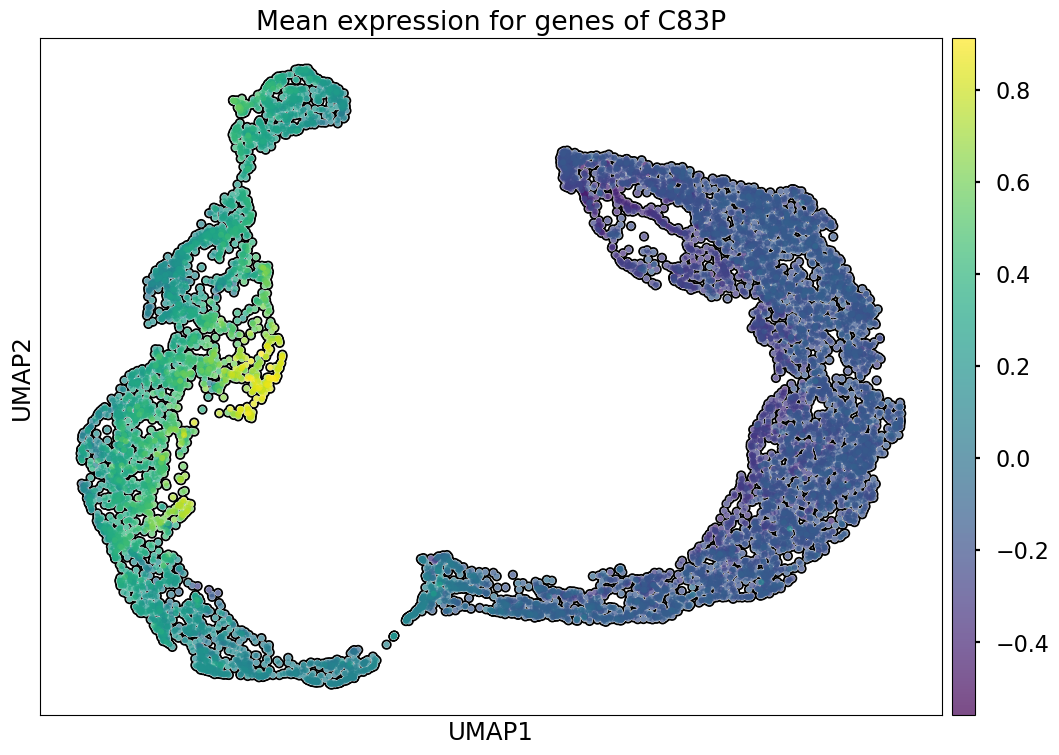

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

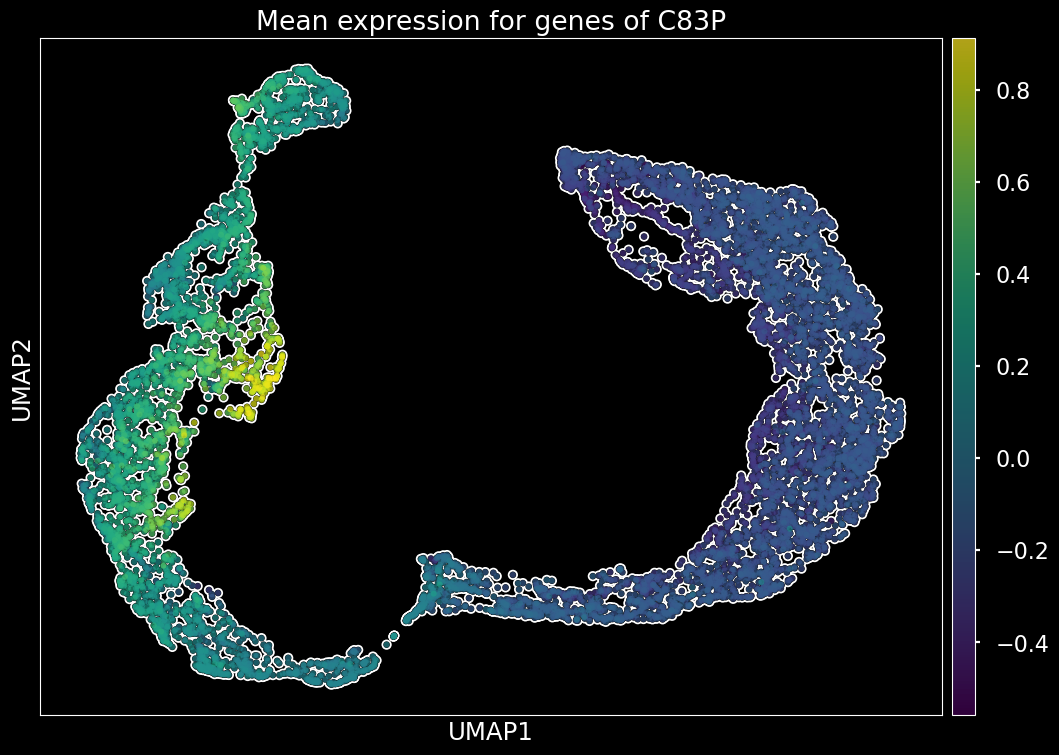

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

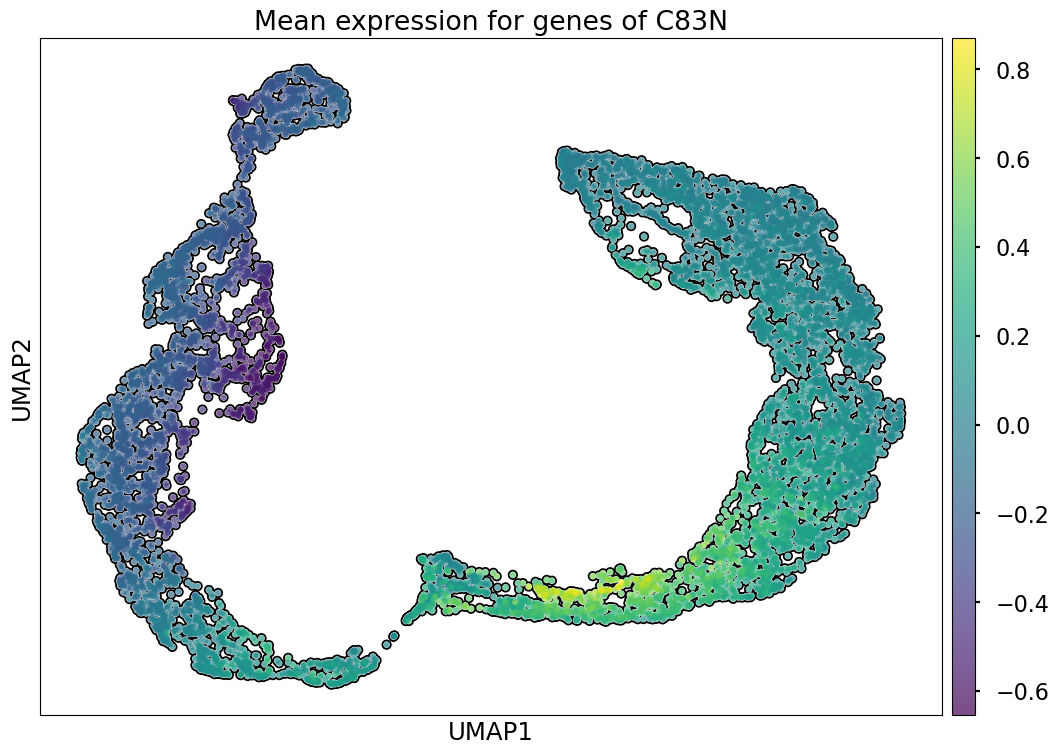

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

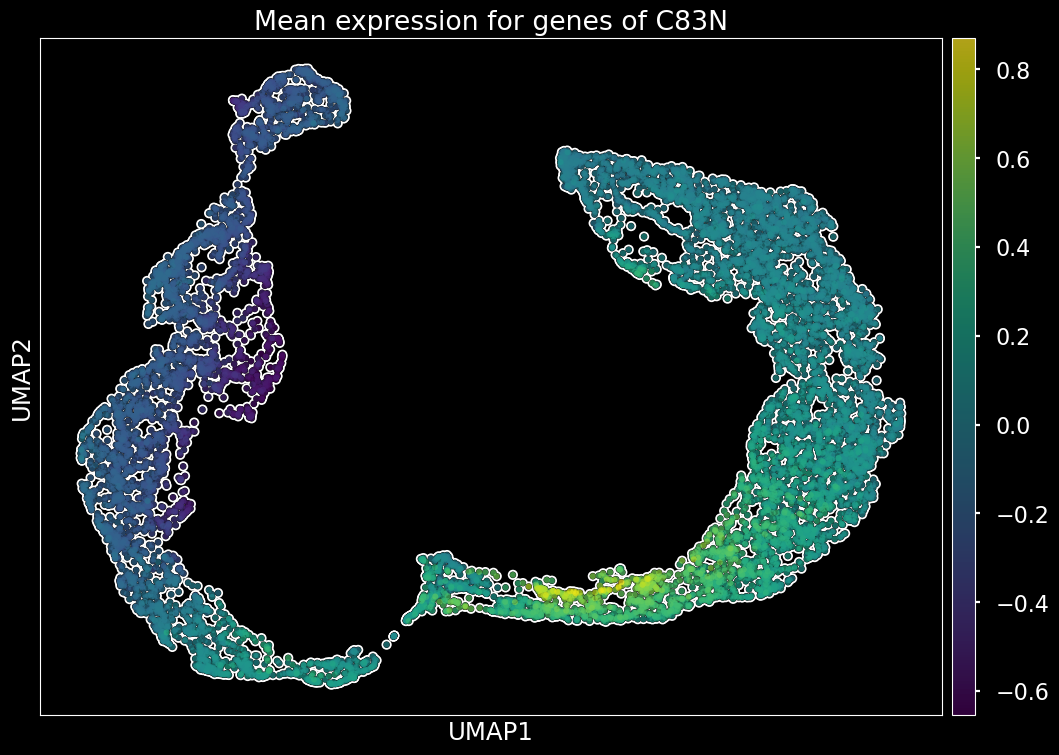

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)